# 02 · Longitudinal structure and outcomes

**Goal.** Understand how people are followed over time and what we could predict: diagnosis, global CDR and CDR Sum of Boxes (CDR-SB).

**Why it matters.** A prediction model needs three things fixed in advance:

1. an **index visit** (the moment we pretend to make the prediction),
2. a **horizon** (how far ahead we predict), and
3. a **target** (what counts as "decline").

We cannot choose these sensibly without knowing how long people are followed, how often they are seen, and how many of them actually decline. This notebook supplies those numbers. It does not choose for you; the decisions are listed at the end.

Only aggregates are shown.

In [1]:
import sys
sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nacc_utils as nu

nu.set_style()
raw = nu.load_uds(["NACCVNUM", "NACCADC", "PACKET", "FORMVER", "NACCUDSD", "CDRGLOB", "CDRSUM", "NACCETPR", "NACCAGE", "NACCDIED"])
df = nu.add_time(nu.clean(raw))
first = df.groupby("NACCID").first()
last = df.groupby("NACCID").last()
print(f"{len(df):,} visits, {df.NACCID.nunique():,} participants, {df.NACCADC.nunique()} centres, "
      f"visits from {df.VISITDATE.dt.year.min()} to {df.VISITDATE.dt.year.max()}")

217,598 visits, 57,038 participants, 46 centres, visits from 2005 to 2026


## 1. How people are followed

NACC participants are invited back about once a year. Some come once, some for twenty years.

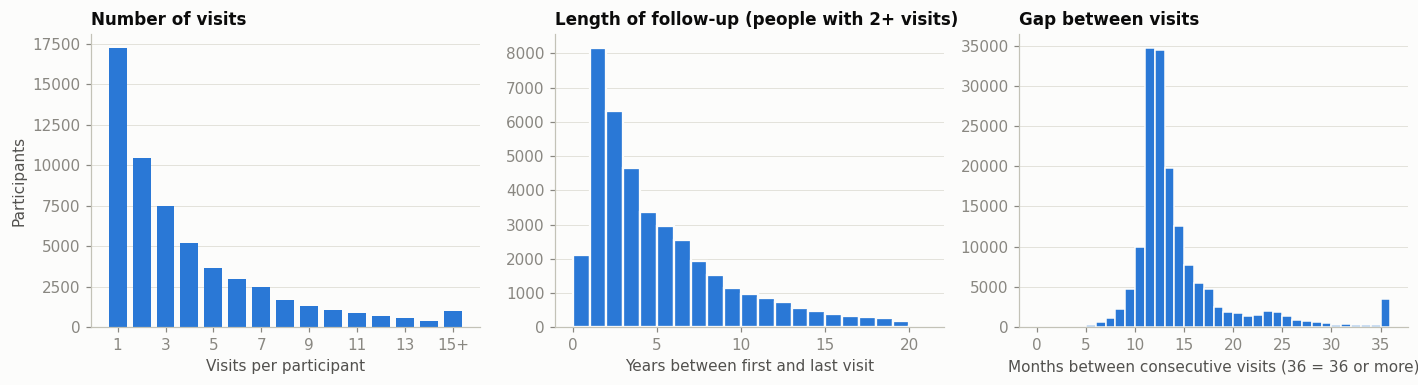

,Participants,% of all
Any visit,57038,100.0
2 or more visits,39798,69.8
3 or more visits,29355,51.5
5 or more visits,16667,29.2


In [2]:
n_vis = df.groupby("NACCID").size()
fu_years = last["years"]
gaps = df.groupby("NACCID")["VISITDATE"].diff().dt.days.dropna() / 30.44

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
vc = n_vis.clip(upper=15).value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color=nu.BLUE, width=0.75)
axes[0].set_xticks([1, 3, 5, 7, 9, 11, 13, 15], ["1", "3", "5", "7", "9", "11", "13", "15+"])
axes[0].set_xlabel("Visits per participant"); axes[0].set_ylabel("Participants"); axes[0].set_title("Number of visits")
axes[1].hist(fu_years[fu_years > 0], bins=np.arange(0, 21.5, 1), color=nu.BLUE, edgecolor="#fcfcfb", linewidth=1.5)
axes[1].set_xlabel("Years between first and last visit"); axes[1].set_title("Length of follow-up (people with 2+ visits)")
axes[2].hist(gaps.clip(upper=36), bins=np.arange(0, 37, 1), color=nu.BLUE, edgecolor="#fcfcfb", linewidth=1)
axes[2].set_xlabel("Months between consecutive visits (36 = 36 or more)"); axes[2].set_title("Gap between visits")
for ax in axes: ax.grid(axis="x", visible=False)
fig.tight_layout(); nu.savefig(fig, "02_followup_structure"); plt.show()

pd.DataFrame({
    "Participants": [len(n_vis), (n_vis >= 2).sum(), (n_vis >= 3).sum(), (n_vis >= 5).sum()],
    "% of all": [100, nu.pct((n_vis >= 2).sum(), len(n_vis)), nu.pct((n_vis >= 3).sum(), len(n_vis)), nu.pct((n_vis >= 5).sum(), len(n_vis))],
}, index=["Any visit", "2 or more visits", "3 or more visits", "5 or more visits"])

In [3]:
print("Follow-up among people with 2+ visits (years): median %.1f, quartiles %.1f to %.1f" %
      (fu_years[fu_years > 0].median(), fu_years[fu_years > 0].quantile(.25), fu_years[fu_years > 0].quantile(.75)))
print("Gap between visits (months): median %.1f; 90%% of gaps are between %.1f and %.1f" %
      (gaps.median(), gaps.quantile(.05), gaps.quantile(.95)))

Follow-up among people with 2+ visits (years): median 3.5, quartiles 2.0 to 6.9
Gap between visits (months): median 12.7; 90% of gaps are between 9.9 and 25.9


**What this means.**

* About 30% of people were seen only once. They can be used to describe the cohort, but they have no outcome, so they cannot train or test a prediction model.
* Visits are roughly yearly, but not exactly. Gaps vary from about 10 months to more than two years. A sequence model must therefore be told the **time** of each visit (for example, years since the index visit), not just its position in the sequence.
* Because people have different numbers of visits, sequences have different lengths. That is a design constraint for the longitudinal model (padding and masking, or summary features such as slopes).

## 2. The data span twenty years and four form versions

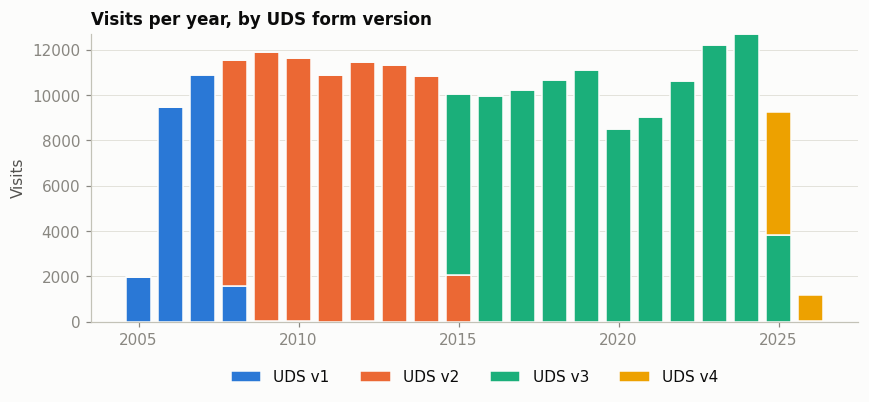

In [4]:
df["version"] = df.FORMVER.map({1.0: "UDS v1", 2.0: "UDS v2", 3.0: "UDS v3", 3.2: "UDS v3", 4.0: "UDS v4"})
by_year = pd.crosstab(df.VISITDATE.dt.year, df.version)
fig, ax = plt.subplots(figsize=(9, 3.4))
bottom = np.zeros(len(by_year))
for col, color in zip(by_year.columns, [nu.BLUE, nu.ORANGE, nu.AQUA, nu.YELLOW]):
    ax.bar(by_year.index, by_year[col], bottom=bottom, label=col, color=color, width=0.8, edgecolor="#fcfcfb", linewidth=1)
    bottom += by_year[col].values
ax.set_ylabel("Visits"); ax.set_title("Visits per year, by UDS form version"); ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
ax.grid(axis="x", visible=False); nu.savefig(fig, "02_visits_per_year"); plt.show()

Version 3 took over in 2015. Someone followed from 2010 to 2020 was tested with MMSE in the first half and MoCA in the second. This is why the outcome should be something that never changed (CDR and diagnosis), and why cognitive test *inputs* need harmonising (notebook 03).

## 3. The three candidate outcomes

| Outcome | Variable | What it is | Strength | Weakness |
|---|---|---|---|---|
| Diagnosis | `NACCUDSD` | Clinician's conclusion: normal, impaired-not-MCI, MCI, dementia | Clinically meaningful, easy to explain | Depends on clinician judgement; people can move back |
| Global CDR | `CDRGLOB` | Overall stage: 0, 0.5, 1, 2, 3 | Standard staging scale | Only five levels, so it changes slowly |
| CDR-SB | `CDRSUM` | Sum of six domain scores, 0 to 18 | Finer scale; the usual endpoint in trials | Many zeros among healthy people |

All three are recorded at every visit in every form version.

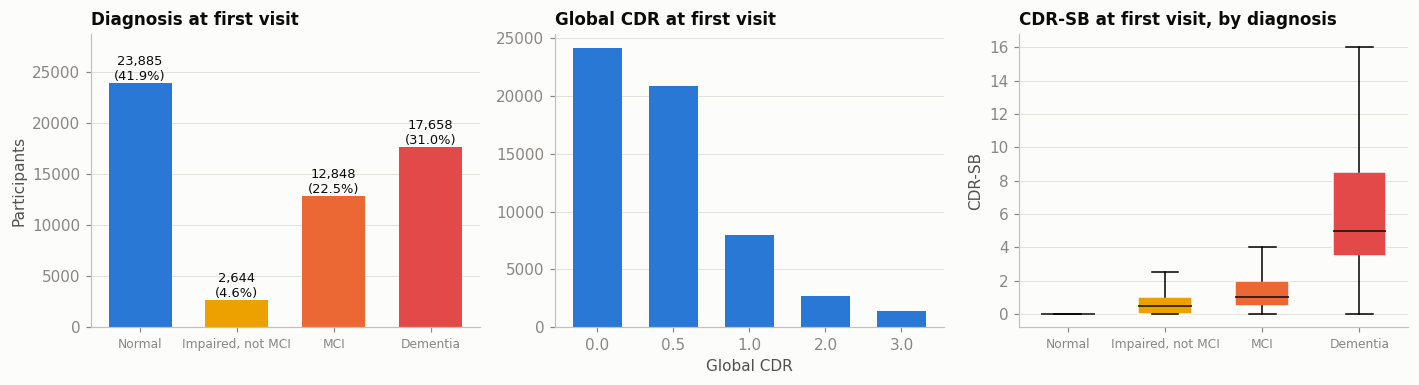

,count,mean,50%,75%,max
NACCUDSD,,,,,
Dementia,17656.0,6.53,5.0,8.5,18.0
"Impaired, not MCI",2644.0,0.87,0.5,1.0,18.0
MCI,12848.0,1.36,1.0,2.0,18.0
Normal,23885.0,0.11,0.0,0.0,11.0


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
dx = first.NACCUDSD.value_counts().reindex([1, 2, 3, 4])
axes[0].bar([nu.DX_LABELS[k] for k in dx.index], dx.values, color=[nu.DX_COLORS[k] for k in dx.index], width=0.65)
for i, v in enumerate(dx.values): axes[0].text(i, v + 300, f"{v:,}\n({nu.pct(v, dx.sum())}%)", ha="center", fontsize=8.5)
axes[0].set_ylim(0, dx.max() * 1.2); axes[0].set_title("Diagnosis at first visit"); axes[0].set_ylabel("Participants"); axes[0].tick_params(axis="x", labelsize=8)
cg = first.CDRGLOB.value_counts().sort_index()
axes[1].bar(cg.index.astype(str), cg.values, color=nu.BLUE, width=0.65); axes[1].set_title("Global CDR at first visit"); axes[1].set_xlabel("Global CDR")
data = [first.loc[first.NACCUDSD == k, "CDRSUM"].dropna() for k in [1, 2, 3, 4]]
bp = axes[2].boxplot(data, vert=True, patch_artist=True, showfliers=False, widths=0.55, medianprops=dict(color=nu.INK))
for patch, k in zip(bp["boxes"], [1, 2, 3, 4]): patch.set(facecolor=nu.DX_COLORS[k], edgecolor="#fcfcfb")
axes[2].set_xticks([1, 2, 3, 4], [nu.DX_LABELS[k] for k in [1, 2, 3, 4]], fontsize=8); axes[2].set_ylabel("CDR-SB"); axes[2].set_title("CDR-SB at first visit, by diagnosis")
for ax in axes: ax.grid(axis="x", visible=False)
fig.tight_layout(); nu.savefig(fig, "02_outcomes_at_baseline"); plt.show()
first.groupby(first.NACCUDSD.map(nu.DX_LABELS))["CDRSUM"].describe()[["count", "mean", "50%", "75%", "max"]].round(2)

**Reading this.**

* At first visit about 42% are cognitively normal, 23% have MCI and 31% already have dementia. NACC centres recruit through memory clinics and volunteers, so this is **not** a sample of the general population. Any risk the model reports applies to people like NACC participants.
* People who already have dementia at the index visit cannot "convert". For an *early prediction* project they are normally excluded from the prediction cohort. That is a cohort decision for you.
* CDR-SB separates the groups well, but for normal people it is almost always 0. A regression model on CDR-SB will see a big spike at zero; this affects the choice of loss and metrics later.

## 4. How do people move between states?

For everyone with at least two visits, compare the first diagnosis with the last one.

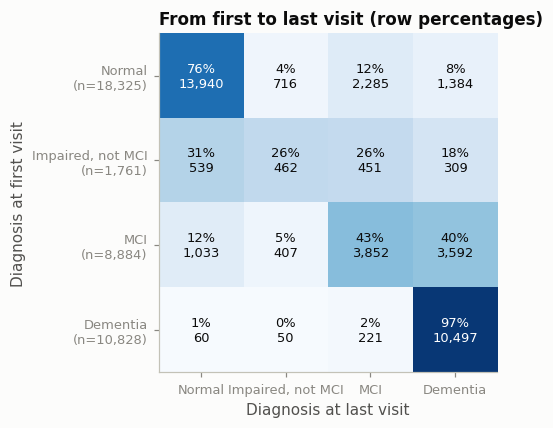

In [6]:
both = first[["NACCUDSD"]].join(last[["NACCUDSD", "years"]], rsuffix="_last")
both = both[(both.years > 0)].dropna()
trans = pd.crosstab(both.NACCUDSD.map(nu.DX_LABELS), both.NACCUDSD_last.map(nu.DX_LABELS))
order = [nu.DX_LABELS[k] for k in [1, 2, 3, 4]]
trans = trans.reindex(index=order, columns=order)
rowpct = trans.div(trans.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(6.2, 4))
im = ax.imshow(rowpct.values, cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(4), order, fontsize=8.5); ax.set_yticks(range(4), [f"{o}\n(n={trans.loc[o].sum():,})" for o in order], fontsize=8.5)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{rowpct.values[i, j]:.0f}%\n{trans.values[i, j]:,}", ha="center", va="center", fontsize=8.5,
                color="white" if rowpct.values[i, j] > 55 else nu.INK)
ax.set_xlabel("Diagnosis at last visit"); ax.set_ylabel("Diagnosis at first visit"); ax.grid(False)
ax.set_title("From first to last visit (row percentages)")
nu.savefig(fig, "02_transition_matrix"); plt.show()

* Most people who start normal stay normal. Decline is the minority class, so **accuracy is a misleading metric**: a model that always says "no decline" would score well. We will need AUROC, AUPRC, sensitivity, specificity and calibration.
* A visible share of people who start with MCI are later rated normal again ("reversion"). Diagnosis is not a one-way street, which is one argument for using CDR-SB change, or for requiring that a conversion is confirmed.

This matrix ignores *when* the change happened and how long each person was followed. The next section fixes that.

## 5. Time to progression, done properly

**The problem.** Suppose we ask "who converts to dementia within 3 years?". Someone who was followed for only 1 year and had not converted is neither a yes nor a no. We simply do not know. This is called **censoring**. If we count such people as "no", we underestimate risk.

**The standard tool** is the Kaplan-Meier estimate. At each time point it uses only the people still being followed. The curves below show the estimated percentage who have progressed by each year.

Events are defined as:
* starting **normal**: first visit with MCI or dementia;
* starting **MCI**: first visit with dementia.

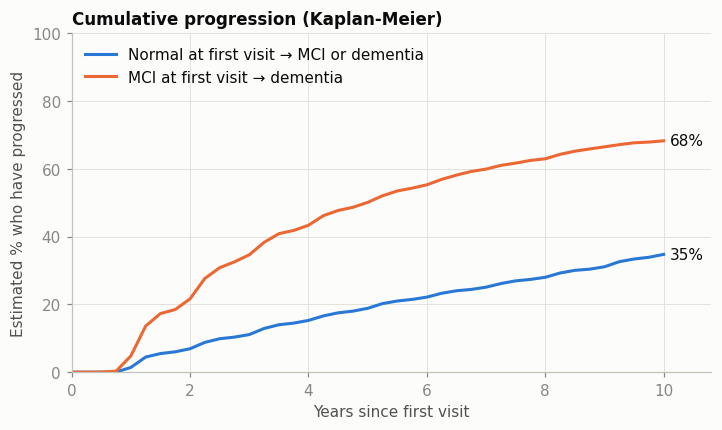

Started with follow-up  \
Cohort                                  Horizon (years)                           
Normal at first visit → MCI or dementia 2                                 18325   
                                        3                                 18325   
                                        5                                 18325   
MCI at first visit → dementia           2                                  8884   
                                        3                                  8884   
                                        5                                  8884   

                                                         Status known at horizon  \
Cohort                                  Horizon (years)                            
Normal at first visit → MCI or dementia 2                                  15068   
                                        3                                  13078   
                                        5                                  10668   
MCI at first visit → dementia           2                                   7025   
                                        3                                   6032   
                                        5                                   5022   

                                                         Events by horizon  \
Cohort                                  Horizon (years)                      
Normal at first visit → MCI or dementia 2                             1154   
                                        3                             1732   
                                        5                             2604   
MCI at first visit → dementia           2                             1707   
                                        3                             2499   
                                        5                             3198   

                                                         Kaplan-Meier risk %  
Cohort                                  Horizon (years)                       
Normal at first visit → MCI or dementia 2                                6.9  
                                        3                               11.1  
                                        5                               18.9  
MCI at first visit → dementia           2                               21.7  
                                        3                               34.6  
                                        5                               50.1

In [7]:
def time_to_event(df, start_dx, event_dx):
    """One row per participant: time of first event, or time of last visit if none."""
    ids = first.index[first.NACCUDSD.isin(start_dx)]
    d = df[df.NACCID.isin(ids) & (df.years > 0)]
    ev = d[d.NACCUDSD.isin(event_dx)].groupby("NACCID")["years"].min()
    lastfu = d.groupby("NACCID")["years"].max()
    out = pd.DataFrame({"time": lastfu, "event": 0})
    out.loc[ev.index, "time"] = ev
    out.loc[ev.index, "event"] = 1
    return out

def kaplan_meier(tte, grid):
    """Estimated cumulative incidence (1 - survival) on a grid of years."""
    t = tte.sort_values("time")
    times = np.sort(t.time[t.event == 1].unique())
    at_risk = np.array([(t.time >= x).sum() for x in times])
    events = np.array([((t.time == x) & (t.event == 1)).sum() for x in times])
    surv = np.cumprod(1 - events / at_risk)
    return np.array([1 - (surv[times <= g][-1] if (times <= g).any() else 1.0) for g in grid]) * 100

grid = np.arange(0, 10.01, 0.25)
cohorts = {"Normal at first visit → MCI or dementia": ([1], [3, 4], nu.BLUE),
           "MCI at first visit → dementia": ([3], [4], nu.ORANGE)}
fig, ax = plt.subplots(figsize=(7.5, 4))
tte = {}
for label, (s, e, color) in cohorts.items():
    tte[label] = time_to_event(df, s, e)
    ci = kaplan_meier(tte[label], grid)
    ax.plot(grid, ci, color=color, label=label)
    ax.text(10.1, ci[-1], f"{ci[-1]:.0f}%", color=nu.INK, va="center")
ax.set_xlabel("Years since first visit"); ax.set_ylabel("Estimated % who have progressed"); ax.set_xlim(0, 10.8); ax.set_ylim(0, 100)
ax.set_title("Cumulative progression (Kaplan-Meier)"); ax.legend(loc="upper left")
nu.savefig(fig, "02_progression_curves"); plt.show()

rows = []
for label, t in tte.items():
    for h in [2, 3, 5]:
        ci = kaplan_meier(t, [h])[0]
        known = ((t.event == 1) & (t.time <= h)) | (t.time >= h)
        rows.append({"Cohort": label, "Horizon (years)": h, "Started with follow-up": len(t),
                     "Status known at horizon": int(known.sum()), "Events by horizon": int(((t.event == 1) & (t.time <= h)).sum()),
                     "Kaplan-Meier risk %": round(ci, 1)})
pd.DataFrame(rows).set_index(["Cohort", "Horizon (years)"])

**How to read the table.** "Status known at horizon" counts people who either had the event before the horizon or were still being followed at the horizon. These are the people who can be given a clean yes/no label for a classifier.

* **MCI to dementia** is common: roughly one in three within 3 years. There are thousands of events, so this target is well powered.
* **Normal to MCI or dementia** is rarer but there are still thousands of events because the normal group is large.
* The longer the horizon, the fewer people have a known status. A 5-year horizon gives more events per person but a smaller cohort, and it excludes everyone enrolled recently, which includes most people with PET (notebook 04).

**Two modelling routes follow from this.**

1. **Fixed-horizon classification** ("dementia within 3 years: yes/no"). Simple to explain and evaluate. Needs a rule for people censored before the horizon (normally: exclude them, and say so).
2. **Survival analysis** (time-to-event, for example Cox models or survival forests). Uses everyone, including the censored. Slightly harder to explain.

A sound plan is to make route 1 the main result and route 2 a robustness check.

## 6. CDR-SB over time

Average CDR-SB at each year of follow-up, grouped by diagnosis at first visit.

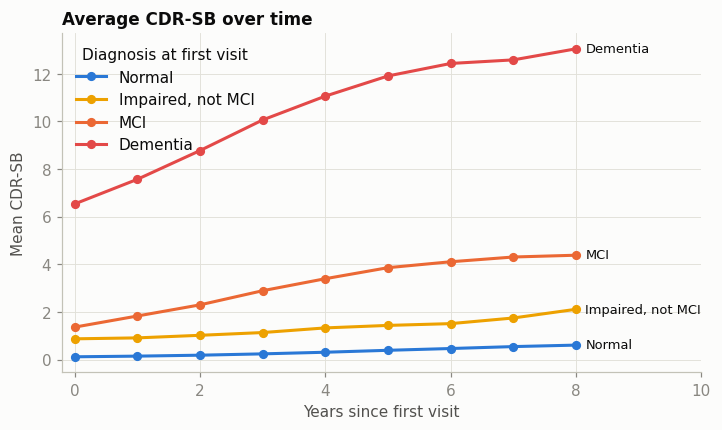

Visits contributing,Normal,"Impaired, not MCI",MCI,Dementia
Year,,,,
0,23895,2647,12855,17673
1,14940,1516,7568,9392
2,12653,1118,5848,6655
3,10564,916,4399,4666
4,9159,760,3357,3281
5,7863,654,2668,2230
6,7070,541,1966,1485
7,5666,439,1437,995
8,4765,363,1041,657


In [8]:
d = df.merge(first[["NACCUDSD"]].rename(columns={"NACCUDSD": "base_dx"}), left_on="NACCID", right_index=True)
d["year_bin"] = d.years.round().astype(int)
traj = d[d.year_bin <= 8].groupby(["base_dx", "year_bin"])["CDRSUM"].agg(["mean", "count"]).reset_index()
fig, ax = plt.subplots(figsize=(7.5, 4))
for k in [1, 2, 3, 4]:
    t = traj[traj.base_dx == k]
    ax.plot(t.year_bin, t["mean"], color=nu.DX_COLORS[k], marker="o", markersize=5, label=nu.DX_LABELS[k])
    ax.text(8.15, t["mean"].iloc[-1], nu.DX_LABELS[k], va="center", fontsize=8.5)
ax.set_xlim(-0.2, 10); ax.set_xlabel("Years since first visit"); ax.set_ylabel("Mean CDR-SB"); ax.legend(title="Diagnosis at first visit", loc="upper left")
ax.set_title("Average CDR-SB over time"); nu.savefig(fig, "02_cdrsb_trajectories"); plt.show()
traj.pivot(index="year_bin", columns="base_dx", values="count").rename(columns=nu.DX_LABELS).rename_axis("Year", axis=0).rename_axis("Visits contributing", axis=1)

* The groups start at different levels and rise at different speeds, which is the signal a longitudinal model should pick up.
* **Caution: survivor bias.** The table shows how quickly the number of visits behind each point shrinks each year. People with severe dementia stop attending, so the dementia line after year 4 or 5 describes only those well enough to keep coming. These average lines are for understanding, not for reporting as results.

## 7. Change in CDR-SB as a target

A continuous target would be "change in CDR-SB from the index visit to about N years later". Below: the change at the visit closest to each horizon (within 6 months), for people who were not demented at first visit.

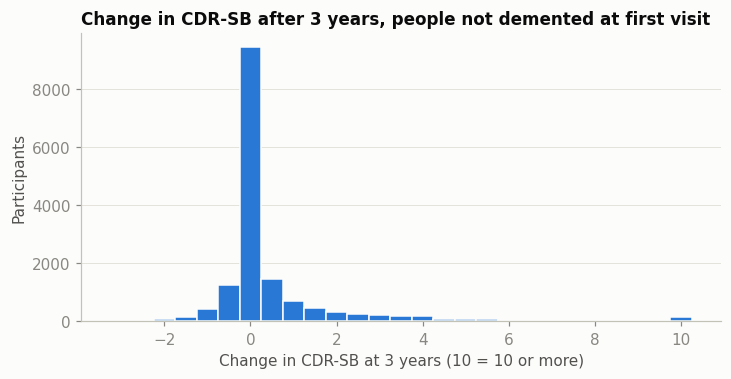

,Participants with a visit near the horizon,Mean change,SD,% with no change or better,% rising by 1 point or more,% rising by 2 points or more
Horizon (years),,,,,,
2,19480,0.35,1.31,74.2,15.9,8.4
3,15749,0.55,1.81,72.3,18.5,11.2
5,11038,0.87,2.53,70.0,21.3,14.5


In [9]:
nd = d[d.base_dx.isin([1, 2, 3])].merge(first[["CDRSUM"]].rename(columns={"CDRSUM": "base_cdrsb"}), left_on="NACCID", right_index=True)
nd["change"] = nd.CDRSUM - nd.base_cdrsb
rows, changes = [], {}
for h in [2, 3, 5]:
    w = nd[(nd.years - h).abs() <= 0.5].copy()
    w["dist"] = (w.years - h).abs()
    w = w.sort_values("dist").groupby("NACCID").first()
    changes[h] = w.change.dropna()
    rows.append({"Horizon (years)": h, "Participants with a visit near the horizon": len(w), "Mean change": round(w.change.mean(), 2),
                 "SD": round(w.change.std(), 2), "% with no change or better": nu.pct((w.change <= 0).sum(), len(w)),
                 "% rising by 1 point or more": nu.pct((w.change >= 1).sum(), len(w)), "% rising by 2 points or more": nu.pct((w.change >= 2).sum(), len(w))})
fig, ax = plt.subplots(figsize=(7.5, 3.4))
bins = np.arange(-3.25, 10.5, 0.5)
ax.hist(changes[3].clip(-3, 10), bins=bins, color=nu.BLUE, edgecolor="#fcfcfb", linewidth=1)
ax.set_xlabel("Change in CDR-SB at 3 years (10 = 10 or more)"); ax.set_ylabel("Participants")
ax.set_title("Change in CDR-SB after 3 years, people not demented at first visit"); ax.grid(axis="x", visible=False)
nu.savefig(fig, "02_cdrsb_change_3y"); plt.show()
pd.DataFrame(rows).set_index("Horizon (years)")

Most people do not change at all, and a minority rise by several points. A regression model trained with squared error on a distribution like this mostly learns to predict "about zero". Two practical consequences:

* a classification version (for example "CDR-SB rises by 1 point or more") is often easier to evaluate and explain than the raw regression;
* if regression is used, report MAE alongside RMSE and compare against the simple baseline "predict no change".

## 8. Who has no follow-up? (Selection bias)

In [10]:
has_fu = (n_vis >= 2).reindex(first.index)
sel = pd.DataFrame({"Participants": first.groupby("NACCUDSD").size(),
                    "% with a follow-up visit": (has_fu.groupby(first.NACCUDSD).mean() * 100).round(1),
                    "Mean age at first visit": first.groupby("NACCUDSD").NACCAGE.mean().round(1)})
sel.index = sel.index.map(nu.DX_LABELS)
sel

,Participants,% with a follow-up visit,Mean age at first visit
NACCUDSD,,,
Normal,23885,76.7,69.3
"Impaired, not MCI",2644,66.6,69.3
MCI,12848,69.1,72.3
Dementia,17658,61.3,72.3


People with dementia at first visit are less likely to return. Whatever cohort we define by "has follow-up" is therefore somewhat healthier than everyone enrolled. This cannot be fixed, but it must be stated as a limitation, and it is one reason the final claim is "retrospective validation in NACC", not "works for all patients".

## 9. Summary and the decisions you need to make

**What we learned.**

* 39,798 people have at least two visits; median follow-up among them is about 3.5 years; visits are roughly yearly with irregular gaps.
* CDR, CDR-SB and diagnosis are available at every visit across all form versions, so any of them can be the outcome.
* Decline is the minority outcome among people who start normal, and common among people who start with MCI.
* Censoring is real: the longer the horizon, the fewer people have a known answer.

**Decisions for the team** (each needs a sentence of justification in the report):

| # | Decision | Options | What the numbers suggest |
|---|---|---|---|
| 1 | Who is in the prediction cohort? | Everyone not demented at index; only normal; only MCI | "Not demented at index" gives the largest cohort and matches "early prediction". Report normal and MCI separately as well. |
| 2 | Main target | Conversion to dementia; conversion to MCI or dementia; CDR-SB rising by 1 or more; CDR-SB change (regression) | Conversion is easiest to defend clinically. CDR-SB rise avoids relying on one clinician label. |
| 3 | Horizon | 2, 3 or 5 years | 3 years balances events against censoring. 5 years loses most people with PET. |
| 4 | How to treat censored people | Exclude from the fixed-horizon label; or use survival models | Exclude for the main model, add a survival model as a check. |
| 5 | What is the index visit? | First visit; or any visit with enough history before it | First visit is simplest. Using a later visit as index lets the model use the *trajectory before it*, which is the point of the longitudinal branch. |
| 6 | Must a conversion be confirmed? | Single visit; or sustained at the next visit | Given the reversions seen above, a sensitivity analysis with confirmed conversion is worth doing. |

Decision 5 deserves care. If the index is always the first visit, there is no earlier history and a sequence model has nothing to read. The longitudinal branch only makes sense if the index visit is placed after two or more earlier visits ("given the first k visits, predict what happens after").